In [1]:
import os
import json
import glob
import numpy as np
import matplotlib.pyplot as plt

In [3]:

def get_homomer_data(families, dim, metric):
    """Fetches and averages standard scalar metrics across samples."""
    base_dir = f"/mnt/hcleroy/PostDoc2/octopus_smelling/opt_bin_resp/data/homomers/families_{families}/dim_{dim}"
    if not os.path.exists(base_dir): return [], [], []
    
    unit_dirs = glob.glob(os.path.join(base_dir, "n_units_*"))
    units_list, means, stds = [], [], []
    
    for unit_dir in unit_dirs:
        try: n_units = int(os.path.basename(unit_dir).split("_")[-1])
        except ValueError: continue
            
        sample_dirs = glob.glob(os.path.join(unit_dir, "sample_*"))
        sample_values = []
        for sample_dir in sample_dirs:
            test_file = os.path.join(sample_dir, "test_results.json")
            if os.path.exists(test_file):
                with open(test_file, 'r') as f:
                    data = json.load(f)
                    if metric in data:
                        sample_values.append(np.mean(data[metric], axis=0))
        if sample_values:
            units_list.append(n_units)
            means.append(np.mean(sample_values, axis=0))
            stds.append(np.std(sample_values, axis=0))
            
    if units_list:
        idx = np.argsort(units_list)
        units_list, means, stds = np.array(units_list)[idx], np.array(means)[idx], np.array(stds)[idx]
    return units_list, means, stds

def get_homomer_rank_distances(families, dim):
    """Specifically extracts dist_rank_1 through dist_rank_10 and rebuilds the array."""
    base_dir = f"/mnt/hcleroy/PostDoc2/octopus_smelling/opt_bin_resp/data/homomers/families_{families}/dim_{dim}"
    if not os.path.exists(base_dir): return [], [], []
    
    unit_dirs = glob.glob(os.path.join(base_dir, "n_units_*"))
    units_list, means_arrays, stds_arrays = [], [], []
    
    for unit_dir in unit_dirs:
        try: n_units = int(os.path.basename(unit_dir).split("_")[-1])
        except ValueError: continue
            
        sample_dirs = glob.glob(os.path.join(unit_dir, "sample_*"))
        sample_profiles = [] # Will hold arrays of shape (10,) for each sample
        
        for sample_dir in sample_dirs:
            test_file = os.path.join(sample_dir, "test_results.json")
            if os.path.exists(test_file):
                with open(test_file, 'r') as f:
                    data = json.load(f)
                    # Extract dist_rank_1 up to dist_rank_10
                    ranks = [np.mean(data[f"dist_rank_{i}"]) for i in range(1, 11) if f"dist_rank_{i}" in data]
                    if ranks: 
                        sample_profiles.append(ranks)
                        
        if sample_profiles:
            units_list.append(n_units)
            means_arrays.append(np.mean(sample_profiles, axis=0))
            stds_arrays.append(np.std(sample_profiles, axis=0))
            
    if units_list:
        idx = np.argsort(units_list)
        units_list, means_arrays, stds_arrays = np.array(units_list)[idx], np.array(means_arrays)[idx], np.array(stds_arrays)[idx]
    return units_list, means_arrays, stds_arrays


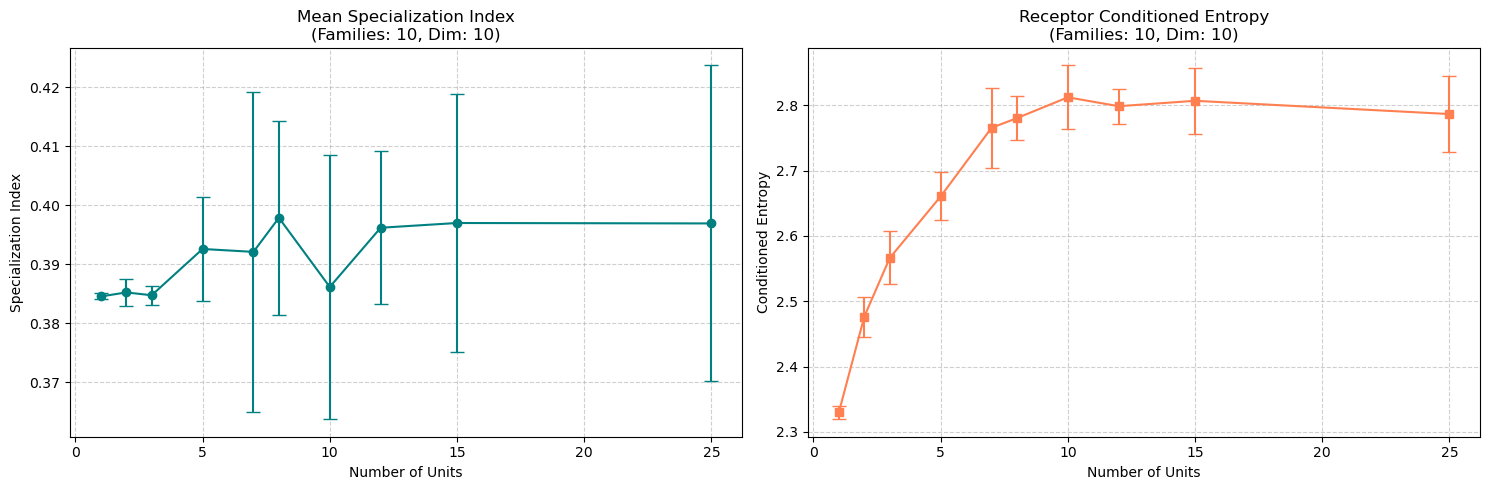

In [5]:
# --- SET YOUR PARAMETERS HERE ---
n_families = 10
latent_dim = 10
# --------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Mean Specialization Index
units, means, stds = get_homomer_data(n_families, latent_dim, "mean_specialization_index")
if len(units) > 0:
    ax1.errorbar(units, means, yerr=stds, fmt='-o', capsize=5, color='teal')
    ax1.set_title(f"Mean Specialization Index\n(Families: {n_families}, Dim: {latent_dim})")
    ax1.set_xlabel("Number of Units")
    ax1.set_ylabel("Specialization Index")
    ax1.grid(True, linestyle='--', alpha=0.6)

# 2. Receptor Conditioned Entropy
units, means, stds = get_homomer_data(n_families, latent_dim, "receptor_conditioned_entropy")
if len(units) > 0:
    ax2.errorbar(units, means, yerr=stds, fmt='-s', capsize=5, color='coral')
    ax2.set_title(f"Receptor Conditioned Entropy\n(Families: {n_families}, Dim: {latent_dim})")
    ax2.set_xlabel("Number of Units")
    ax2.set_ylabel("Conditioned Entropy")
    ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


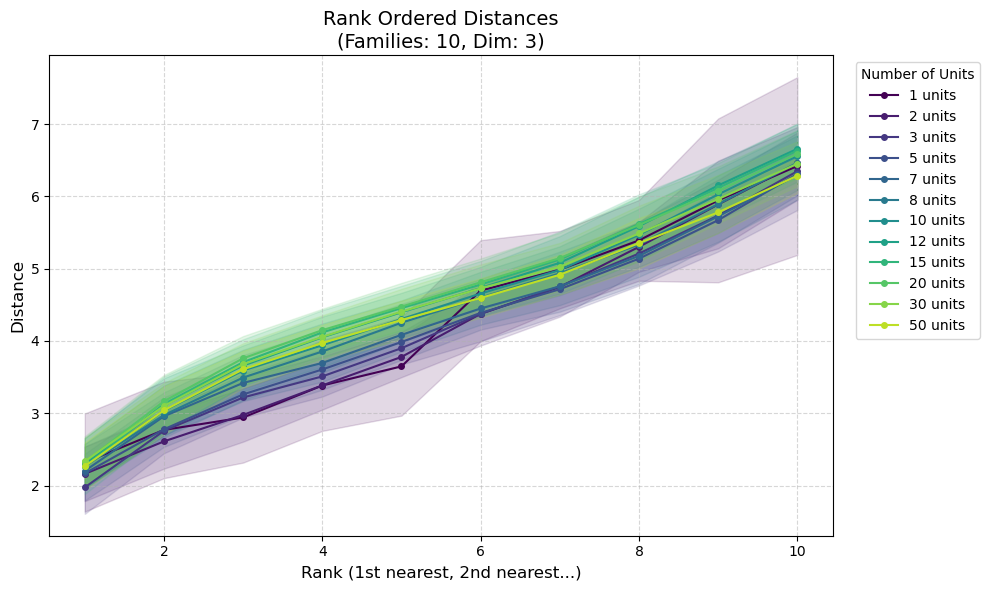

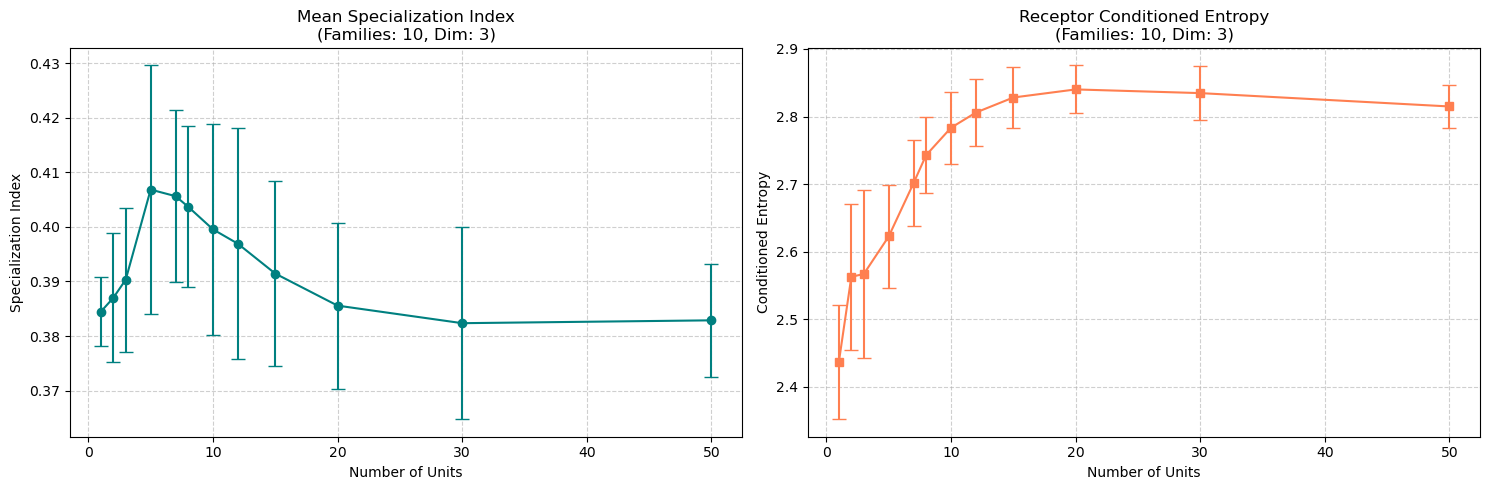

In [25]:
# --- SET YOUR PARAMETERS HERE ---
n_families = 10
latent_dim = 3
# --------------------------------

# 1. Plot Rank Ordered Distances
units, means_arrays, stds_arrays = get_homomer_rank_distances(n_families, latent_dim)

if len(units) > 0:
    plt.figure(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(units)))
    
    for i, (n_units, means, stds) in enumerate(zip(units, means_arrays, stds_arrays)):
        ranks = np.arange(1, len(means) + 1)
        plt.plot(ranks, means, marker='o', markersize=4, label=f"{n_units} units", color=colors[i])
        plt.fill_between(ranks, means - stds, means + stds, alpha=0.15, color=colors[i])
        
    plt.title(f"Rank Ordered Distances\n(Families: {n_families}, Dim: {latent_dim})", fontsize=14)
    plt.xlabel("Rank (1st nearest, 2nd nearest...)", fontsize=12)
    plt.ylabel("Distance", fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Number of Units")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# 2. Plot Specialization Index & Conditioned Entropy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

units, means, stds = get_homomer_data(n_families, latent_dim, "mean_specialization_index")
if len(units) > 0:
    ax1.errorbar(units, means, yerr=stds, fmt='-o', capsize=5, color='teal')
    ax1.set_title(f"Mean Specialization Index\n(Families: {n_families}, Dim: {latent_dim})")
    ax1.set_xlabel("Number of Units")
    ax1.set_ylabel("Specialization Index")
    ax1.grid(True, linestyle='--', alpha=0.6)

units, means, stds = get_homomer_data(n_families, latent_dim, "receptor_conditioned_entropy")
if len(units) > 0:
    ax2.errorbar(units, means, yerr=stds, fmt='-s', capsize=5, color='coral')
    ax2.set_title(f"Receptor Conditioned Entropy\n(Families: {n_families}, Dim: {latent_dim})")
    ax2.set_xlabel("Number of Units")
    ax2.set_ylabel("Conditioned Entropy")
    ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [19]:
import json
import os

# --- SET PARAMETERS TO PEEK INTO ONE FILE ---
n_families = 10
latent_dim = 3
n_units_to_check = 5  # Just picking one that exists
# --------------------------------------------

sample_file = f"/mnt/hcleroy/PostDoc2/octopus_smelling/opt_bin_resp/data/homomers/families_{n_families}/dim_{latent_dim}/n_units_{n_units_to_check}/sample_0_20260416_170444/test_results.json"

if os.path.exists(sample_file):
    with open(sample_file, 'r') as f:
        data = json.load(f)
        print("Available metrics in your JSON files:")
        for key in data.keys():
            print(f" - '{key}'")
else:
    print(f"File not found: {sample_file}\nMake sure the parameters above match an experiment you've run.")


Available metrics in your JSON files:
 - 'full_array_entropy'
 - 'mean_receptor_distance'
 - 'conditional_entropy_family'
 - 'mutual_information_family'
 - 'conditional_entropy_concentration'
 - 'mutual_information_concentration'
 - 'receptor_distances'
 - 'dist_rank_1'
 - 'dist_rank_2'
 - 'dist_rank_3'
 - 'dist_rank_4'
 - 'dist_rank_5'
 - 'dist_rank_6'
 - 'dist_rank_7'
 - 'dist_rank_8'
 - 'dist_rank_9'
 - 'dist_rank_10'
 - 'mean_specialization_index'
 - 'receptor_conditioned_entropy'
